In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Shared style ----------
BLUE, ORANGE, RED, GRAY = "#3B7DB8", "#E8833A", "#D9534F", "#9A9A9A"

plt.rcParams.update({
    "savefig.dpi": 200,
    "font.size": 10,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.axisbelow": True,
})


def leader_chart(csv_path, name_col, count_col, subtitle, footnote, outfile):
    """Horizontal bars: the #1 per decade, win rate with wins/races labels."""
    df = pd.read_csv(csv_path)
    top = df[df["rank_in_decade"] == 1].reset_index(drop=True)
    incomplete = top["decade"] == 2020
    labels = [f"{d}s{'*' if inc else ''}" for d, inc in zip(top["decade"], incomplete)]
    best = top["win_rate_pct"].idxmax()

    fig, ax = plt.subplots(figsize=(10, 5.5))
    bars = ax.barh(labels, top["win_rate_pct"], height=0.65,
                   color=[ORANGE if i == best else BLUE for i in top.index])

    for i, (bar, row) in enumerate(zip(bars, top.itertuples())):
        if incomplete[i]:
            bar.set_hatch("//")
            bar.set_edgecolor("white")
        y = bar.get_y() + bar.get_height() / 2
        name = getattr(row, name_col)
        ax.text(0.8, y, name, color="white", va="center", fontweight="bold")
        n = getattr(row, count_col)
        ax.text(row.win_rate_pct + 0.8, y,
                f"{row.win_rate_pct:.1f}%  ({row.wins}/{n})", va="center", fontsize=9)

    ax.invert_yaxis()
    ax.set_xlim(0, 66)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("Win rate, %")
    ax.set_title(subtitle[0], loc="left", pad=28)
    ax.text(0, 1.03, subtitle[1], transform=ax.transAxes, fontsize=10, color=GRAY)
    fig.text(0.01, 0.01, footnote, fontsize=8, color=GRAY)

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(outfile, bbox_inches="tight")
    plt.show()

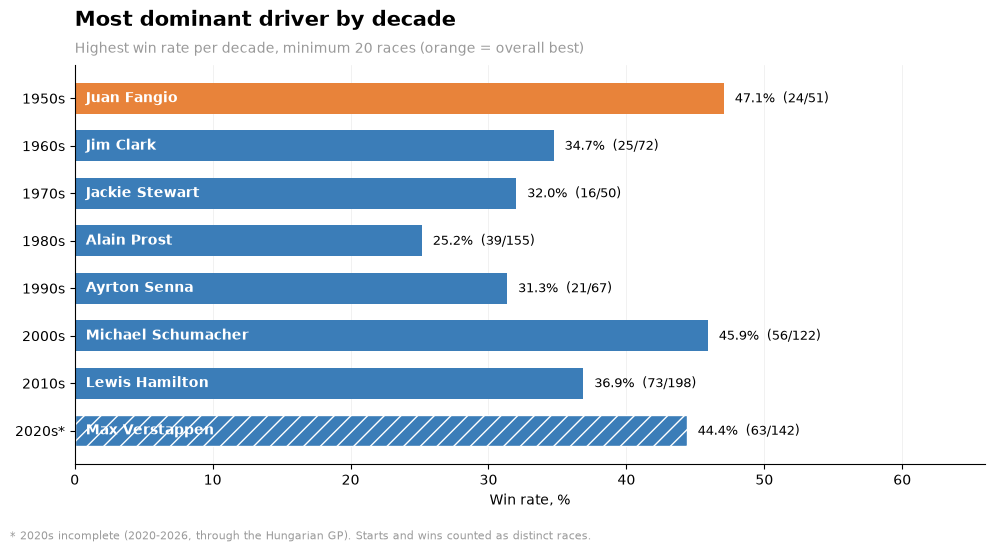

In [44]:
leader_chart(
    "../results/q1_dominant_drivers.csv",
    name_col="driver_name", count_col="starts",
    subtitle=("Most dominant driver by decade",
              "Highest win rate per decade, minimum 20 races (orange = overall best)"),
    footnote="* 2020s incomplete (2020-2026, through the Hungarian GP). "
             "Starts and wins counted as distinct races.",
    outfile="../charts/q1_dominant_drivers.png",
)

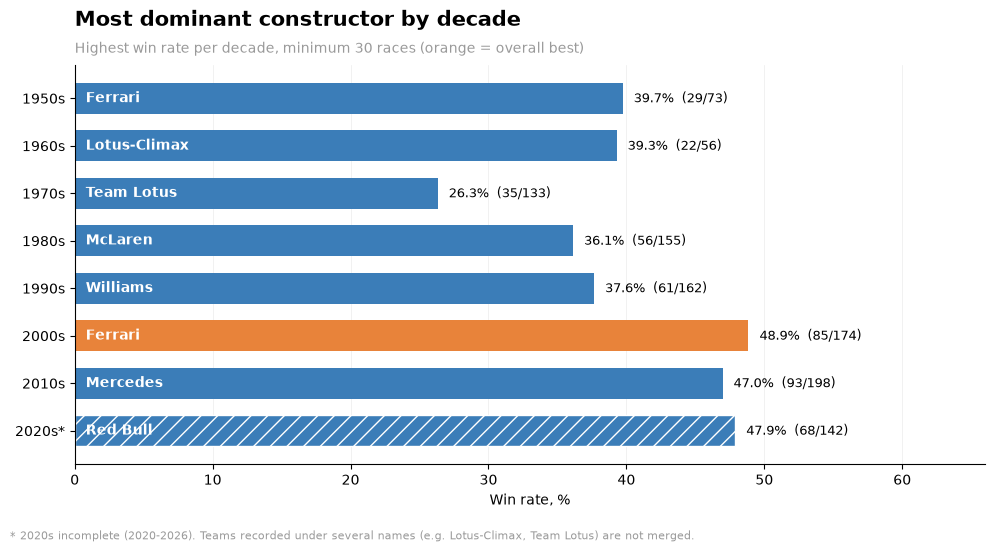

In [45]:
leader_chart(
    "../results/q2_constructor_dominance.csv",
    name_col="constructor_name", count_col="races",
    subtitle=("Most dominant constructor by decade",
              "Highest win rate per decade, minimum 30 races (orange = overall best)"),
    footnote="* 2020s incomplete (2020-2026). Teams recorded under several names "
             "(e.g. Lotus-Climax, Team Lotus) are not merged.",
    outfile="../charts/q2_constructor_dominance.png",
)

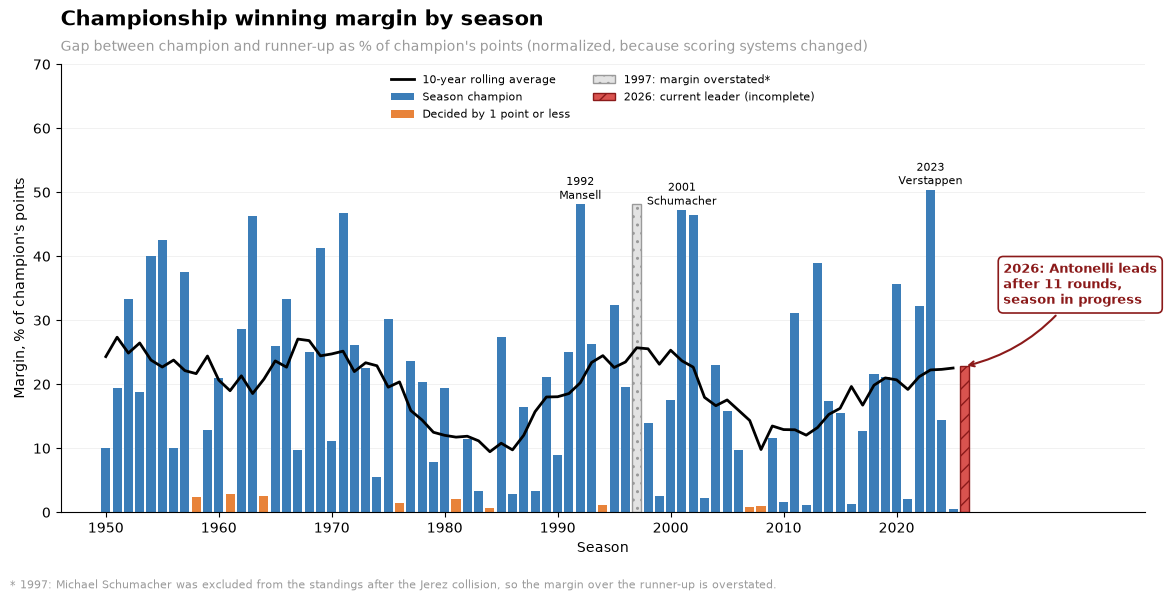

In [48]:
df = pd.read_csv("../results/q3_season_champions.csv")

complete = df[df["year"] < 2026].copy()
current = df[df["year"] == 2026]

close = complete["margin"] <= 1          # decided by 1 point or less
anomaly = complete["year"] == 1997       # Schumacher excluded from standings
regular = ~close & ~anomaly

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(complete.loc[regular, "year"], complete.loc[regular, "margin_pct"],
       color=BLUE, label="Season champion")
ax.bar(complete.loc[close, "year"], complete.loc[close, "margin_pct"],
       color=ORANGE, label="Decided by 1 point or less")
ax.bar(complete.loc[anomaly, "year"], complete.loc[anomaly, "margin_pct"],
       color="#E3E3E3", edgecolor=GRAY, hatch="..",
       label="1997: margin overstated*")

if not current.empty:
    row = current.iloc[0]
    leader = row["driver_name"].split()[-1]

    ax.bar(current["year"], current["margin_pct"], color=RED, hatch="//",
           edgecolor="#8B1A1A", linewidth=1,
           label="2026: current leader (incomplete)")

    ax.annotate(
        f"2026: {leader} leads\nafter 11 rounds,\nseason in progress",
        xy=(row["year"], row["margin_pct"]),
        xytext=(28, 42), textcoords="offset points",
        ha="left", va="bottom", fontsize=9, fontweight="bold", color="#8B1A1A",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#8B1A1A", lw=1.2),
        arrowprops=dict(arrowstyle="->", color="#8B1A1A", lw=1.5,
                        connectionstyle="arc3,rad=-0.2"),
    )

trend = (complete.set_index("year")["margin_pct"]
         .rolling(10, center=True, min_periods=5).mean())
ax.plot(trend.index, trend.values, color="black", linewidth=2,
        label="10-year rolling average")

# Label the 3 largest genuine margins (1997 is excluded as a data anomaly)
for _, row in complete[complete["year"] != 1997].nlargest(3, "margin_pct").iterrows():
    ax.annotate(f"{int(row['year'])}\n{row['driver_name'].split()[-1]}",
                (row["year"], row["margin_pct"]),
                textcoords="offset points", xytext=(0, 4),
                ha="center", fontsize=8)

ax.set_ylim(0, 70)
ax.set_xlim(1946, 2042)
ax.set_xticks(range(1950, 2030, 10))
ax.grid(axis="x", visible=False)
ax.set_xlabel("Season")
ax.set_ylabel("Margin, % of champion's points")
ax.set_title("Championship winning margin by season", loc="left", pad=28)
ax.text(0, 1.03,
        "Gap between champion and runner-up as % of champion's points "
        "(normalized, because scoring systems changed)",
        transform=ax.transAxes, fontsize=10, color=GRAY)
ax.legend(loc="upper center", ncol=2, fontsize=8, frameon=False)

fig.text(0.01, 0.01,
         "* 1997: Michael Schumacher was excluded from the standings after the "
         "Jerez collision, so the margin over the runner-up is overstated.",
         fontsize=8, color=GRAY)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("../charts/q3_championship_margins.png", bbox_inches="tight")
plt.show()

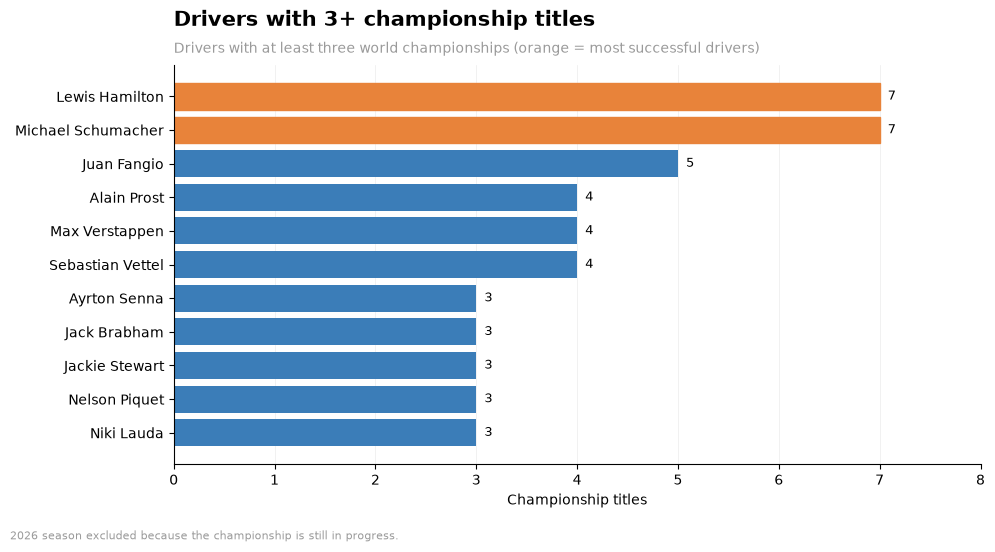

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../results/q3_titles_by_driver.csv")

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(
    df["driver_name"],
    df["titles"],
    color=BLUE
)

# выделяем лидеров
max_titles = df["titles"].max()

for bar, titles in zip(bars, df["titles"]):
    if titles == max_titles:
        bar.set_color(ORANGE)

ax.invert_yaxis()

for bar in bars:
    ax.text(
        bar.get_width() + 0.08,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())}",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, 8)

ax.grid(axis="y", visible=False)

ax.set_xlabel("Championship titles")

ax.set_title("Drivers with 3+ championship titles", loc="left", pad=28)

ax.text(
    0,
    1.03,
    "Drivers with at least three world championships "
    "(orange = most successful drivers)",
    transform=ax.transAxes,
    fontsize=10,
    color=GRAY
)

fig.text(
    0.01,
    0.01,
    "2026 season excluded because the championship is still in progress.",
    fontsize=8,
    color=GRAY
)

plt.tight_layout(rect=[0, 0.04, 1, 1])

plt.savefig(
    "../charts/q3_titles_by_driver.png",
    bbox_inches="tight"
)

plt.show()

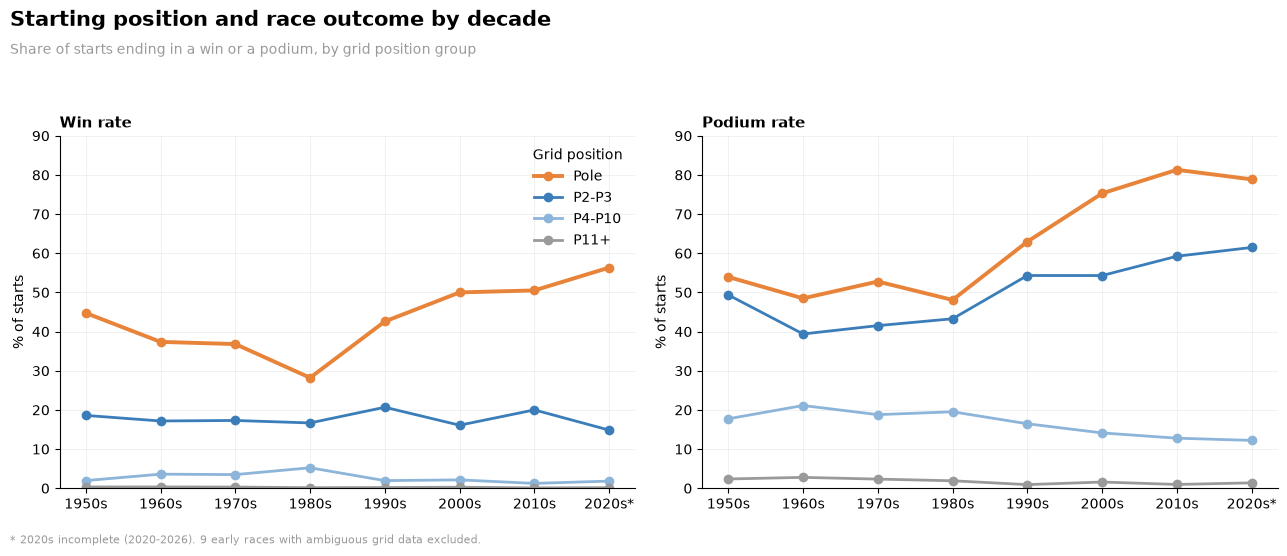

In [50]:
df = pd.read_csv("../results/q4_grid_groups.csv")

order = ["Pole", "P2-P3", "P4-P10", "P11+"]
colors = {"Pole": ORANGE, "P2-P3": BLUE, "P4-P10": "#8DB4D9", "P11+": GRAY}
decades = sorted(df["decade"].unique())
tick_labels = [f"{d}s" for d in decades]
tick_labels[-1] += "*"

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
panels = [(axes[0], "win_rate_pct", "Win rate"),
          (axes[1], "podium_rate_pct", "Podium rate")]

for ax, col, title in panels:
    for group in order:
        sub = df[df["grid_group"] == group]
        ax.plot(sub["decade"], sub[col], marker="o", color=colors[group],
                linewidth=2.8 if group == "Pole" else 2, label=group)
    ax.set_xticks(decades)
    ax.set_xticklabels(tick_labels)
    ax.set_ylim(0, 90)
    ax.set_ylabel("% of starts")
    ax.set_title(title, loc="left", fontsize=11)

axes[0].legend(title="Grid position", frameon=False)
fig.suptitle("Starting position and race outcome by decade",
             x=0.01, ha="left", fontsize=15, fontweight="bold")
fig.text(0.01, 0.9, "Share of starts ending in a win or a podium, by grid position group",
         fontsize=10, color=GRAY)
fig.text(0.01, 0.01,
         "* 2020s incomplete (2020-2026). 9 early races with ambiguous grid data excluded.",
         fontsize=8, color=GRAY)

plt.tight_layout(rect=[0, 0.04, 1, 0.88])
plt.savefig("../charts/q4_grid_groups.png", bbox_inches="tight")
plt.show()